# Classifing with decision trees, random forests, pruning, interpretability, k-NN


In [ ]:
import pandas as pd

RNG = 42

## Decision Trees


1. Load the _Adult Census Income_ dataset using $\texttt{fetch\_openml('adult',\ version=2)}$ and perform exploratory data analysis: column types, missing values, class distribution, splitting features into numerical and categorical, $P(\text{target}=1 \mid \text{feature})$ for categorical features.


### Data exploration


In [ ]:
from sklearn.datasets._openml import fetch_openml

dataset_name = "Adult Census Income"

try:
    ds = fetch_openml(name="adult", version=2, as_frame=True, parser="auto")
    df = ds.frame
    df["income"] = (df["class"] == ">50K").astype(int)
    df = df.drop(columns=["class"])
    target_col = "income"
    print(
        f"Dataset '{dataset_name}' loaded successfully: {df.shape[0]} samples, {df.shape[1]} features."
    )
    print(f"Class distribution:\n{df[target_col].value_counts()}")
    print(f"Baseline = {df[target_col].mean():.3f}")
except Exception as e:
    print(f"Error fetching dataset: {e}")
    df = None

df.head()

In [ ]:
info = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing": df.isnull().sum(),
        "missing%": df.isnull().mean() * 100,
        "nunique": df.nunique(),
    }
)
info

In [ ]:
num_cols = df.select_dtypes(include=["number"]).columns.drop(target_col).tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"({len(num_cols)}) Numerical columns: {num_cols}")
print(f"({len(cat_cols)}) Categorical columns: {cat_cols}")

In [ ]:
df[num_cols].describe().T

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

if cat_cols:
    fig, axes = plt.subplots(2, min(3, len(cat_cols)), figsize=(16, 8))
    axes = np.array(axes).ravel()
    for i, col in enumerate(cat_cols[:6]):
        vc = df.groupby(col)[target_col].mean().sort_values(ascending=False).head(10)
        vc.plot(
            kind="barh", ax=axes[i], title=f"{col} vs {target_col}", color="skyblue"
        )
        axes[i].axvline(
            df[target_col].mean(), color="red", linestyle="--", label="Baseline"
        )
        axes[i].set_title(f"P({target_col}=1 | {col})")
        axes[i].set_xlabel("")
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()

### Preprocessing


2. Build a preprocessing pipeline using $\texttt{ColumnTransformer}$, combining $\texttt{SimpleImputer}$ with $\texttt{OrdinalEncoder}$ for categorical features. Perform a stratified $75\%/25\%$ split.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split

numeric_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
        ),
    ]
)
preprocessor = ColumnTransformer(
    [
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

feature_names = num_cols + cat_cols
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RNG
)


print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test set: {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"Class distribution in train: {y_train.value_counts(normalize=True)}")
print(f"Class distribution in test: {y_test.value_counts(normalize=True)}")

3. Train a _full tree_ (without regularization) and observe overfitting: the difference between training and test accuracy. What depth was reached?


In [ ]:
from sklearn.tree import DecisionTreeClassifier

base_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("clf", DecisionTreeClassifier(random_state=RNG)),
    ]
)

base_pipeline.fit(X_train, y_train)
print("Full tree:")
print(f"\tdepth: {base_pipeline.named_steps['clf'].get_depth()}")
print(f"\tleaves: {base_pipeline.named_steps['clf'].get_n_leaves()}")
print(f"\tTrain accuracy: {base_pipeline.score(X_train, y_train):.4f}")
print(f"\tTest accuracy: {base_pipeline.score(X_test, y_test):.4f}")

4. Using 10-fold cross-validation for $\texttt{max\_depth} \in \{1, \ldots, 20\}$, illustrate the bias-variance curve. Identify the optimal depth.


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

depths = list(range(1, 21))
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RNG)
cv_scores = []

for d in depths:
    pipeline = Pipeline(
        [
            ("preprocessor", preprocessor),
            ("clf", DecisionTreeClassifier(max_depth=d, random_state=RNG)),
        ]
    )
    s = cross_val_score(
        pipeline, X_train, y_train, cv=kf, scoring="balanced_accuracy", n_jobs=-1
    )
    cv_scores.append((s.mean(), s.std()))

In [ ]:
print(
    f"Best depth: {depths[np.argmax([s[0] for s in cv_scores])]} with CV score: {max(cv_scores)[0]:.4f} ± {max(cv_scores)[1]:.4f}"
)

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(
    depths,
    [s[0] for s in cv_scores],
    yerr=[s[1] for s in cv_scores],
    marker="o",
    color="skyblue",
    label="CV Score",
)
ax.axvline(
    depths[np.argmax([s[0] for s in cv_scores])],
    color="red",
    linestyle="--",
    label="Best Depth",
)
ax.set_xlabel("Tree Depth")
ax.set_ylabel("Cross-Validation Balanced Accuracy")
ax.set_title("Bias-Variance Tradeoff")
ax.legend()
ax.set_xticks(depths)
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
cpp_alphas = base_pipeline.named_steps["clf"].cost_complexity_pruning_path(
    preprocessor.fit_transform(X_train), y_train
)
ccp_alphas, impurities = cpp_alphas.ccp_alphas, cpp_alphas.impurities
print(f"Number of effective alphas: {len(ccp_alphas)}")
print(f"Alphas: {ccp_alphas[:5]} ... {ccp_alphas[-5:]}")

In [ ]:
stats = []

for alpha in ccp_alphas:  # Test every 10th alpha for speed
    pipeline = Pipeline(
        [
            ("preprocessor", preprocessor),
            ("clf", DecisionTreeClassifier(random_state=RNG, ccp_alpha=alpha)),
        ]
    )
    s = cross_val_score(
        pipeline, X_train, y_train, cv=kf, scoring="balanced_accuracy", n_jobs=-1
    )
    stats.append((alpha, s.mean(), s.std()))
    print(f"Alpha: {alpha:.5f}, CV Score: {s.mean():.4f} ± {s.std():.4f}")

5. For the full tree, call $\texttt{cost\_complexity\_pruning\_path()}$ to obtain the sequence $\alpha_0 < \alpha_1 < \ldots < \alpha_m$. For each $\alpha$:
   - train a tree with $\texttt{ccp\_alpha}=\alpha$,
   - record depth, number of leaves, train accuracy, test accuracy,
   - visualize train/test accuracy and number of leaves as a function of $\alpha$.

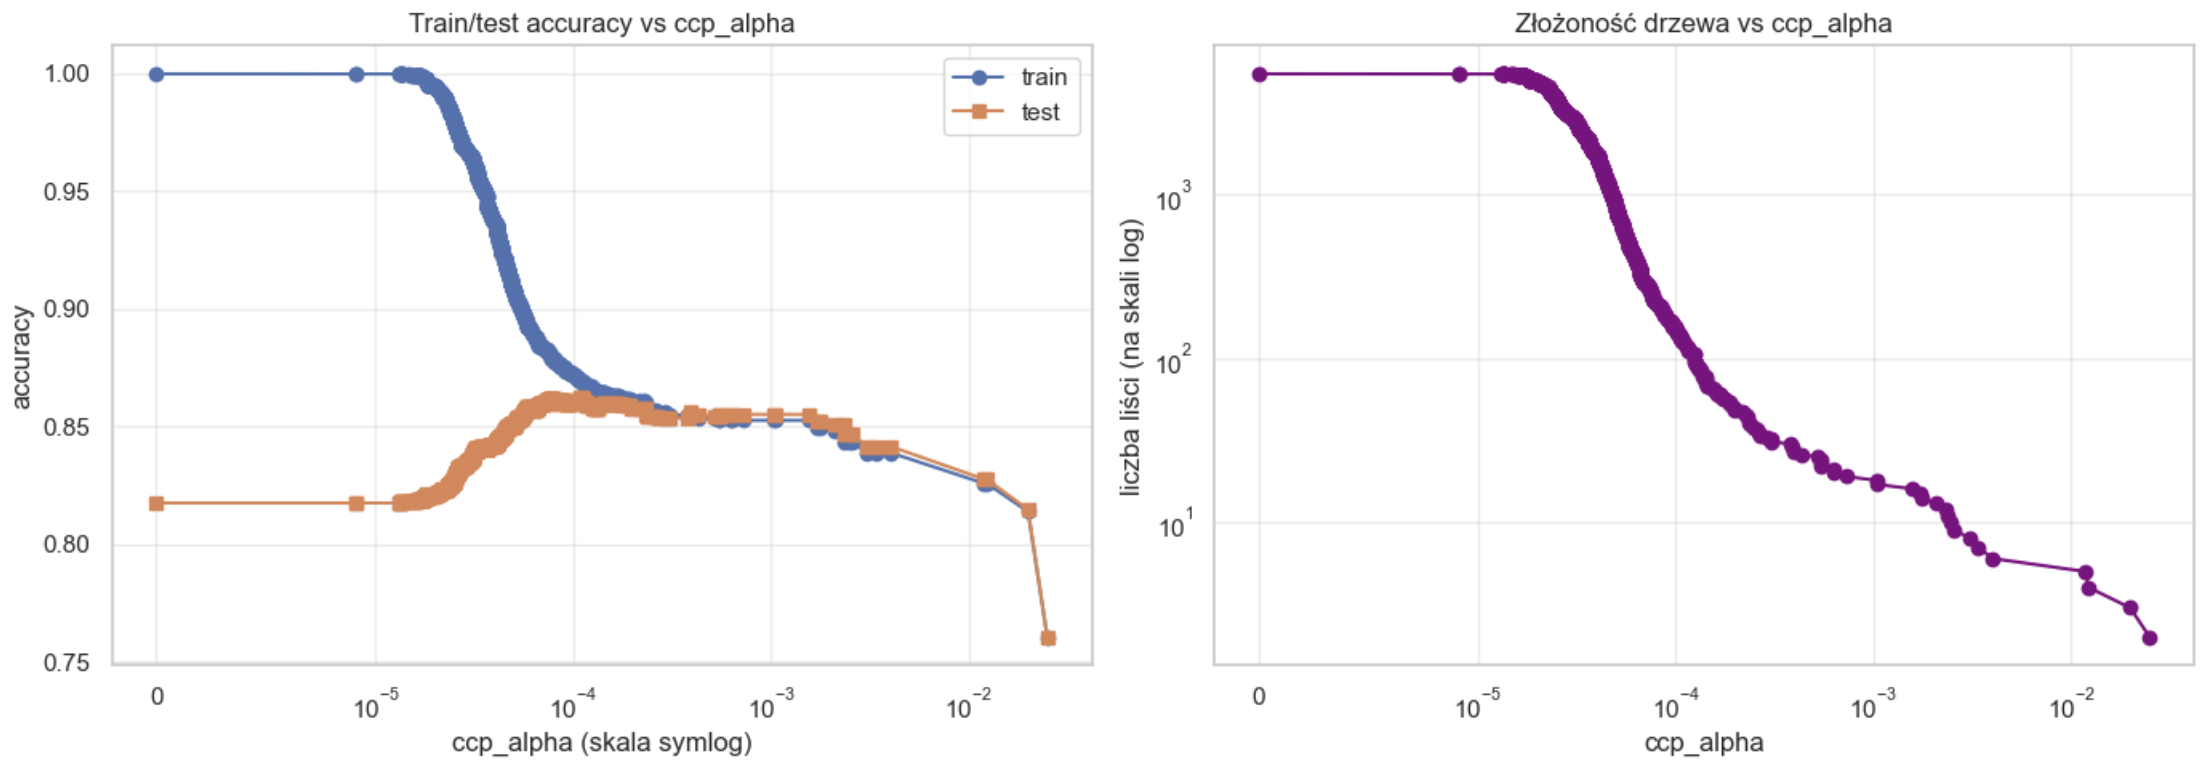

Image 1: Expected shape of the CCP curve. For $\alpha \rightarrow 0$ the tree is full (overfit); for $\alpha \rightarrow \alpha_{\max}$ the tree reduces to a root. We identify the optimum by CV.


6. Find the optimal $\alpha^*$ using $\texttt{GridSearchCV}$ with $\texttt{param\_grid=\{'ccp\_alpha':\ alphas\}}$ on 10-fold cross-validation.


7. **Regularization strategy comparison**. Build a comparison table of four models:
   - a) full tree,
   - b) pre-pruning with $\texttt{max\_depth=best\_d}$,
   - c) combined pre-pruning ($\texttt{max\_depth=10}$, $\texttt{min\_samples\_leaf=20}$, $\texttt{min\_impurity\_decrease=1e{-}4}$),
   - d) post-pruning with $\texttt{ccp\_alpha}=\alpha^*$.

   Columns: depth, number of leaves, train/test accuracy, $F_1$, overfit gap. _Comment: which strategy would you choose for production and why?_


8. **Tree visualization**. For a tree limited to depth 3, generate:
   - visualization via $\texttt{export\_graphviz()}\ \rightarrow\ \texttt{graphviz.Source()}$,
   - visualization via $\texttt{dtreeviz}$ (histograms of distributions in nodes, pie charts in leaves).

   Compare both representations.


9. **Interpretability**. For the CCP-pruned tree, compute three types of feature importance:
   - a) built-in ($\texttt{feature\_importances\_}$),
   - b) $\texttt{permutation\_importance}$ on the test set,
   - c) SHAP values ($\texttt{shap.TreeExplainer}$): $\texttt{shap.summary\_plot}$ for 1000 random records and $\texttt{shap.plots.waterfall}$ for one selected prediction.

   _Comment: are the rankings from the three methods consistent? Where might the differences come from?_


10. _(optional)_ **Fairness audit**: does the model predict the positive class with different accuracy for subgroups defined by $\texttt{sex}$ and $\texttt{race}$? Compare _demographic parity_ and _equalized odds_ in both subgroups.


## Random Forests


Before implementing, review the key theoretical concepts:

1. **Error decomposition**: $\mathbb{E}[(\hat{f}(x) - y)^2] = \text{bias}^2 + \text{variance} + \sigma^2_{\text{noise}}$. A deep tree has low bias and high variance.
2. **Bagging** (Breiman 1996): $B$ independent bootstrap samples generate $B$ trees. The variance of their mean is $\rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$, where $\rho$ is the average pairwise correlation between trees.
3. **Random Forest** (Breiman 2001): additional randomization via $\texttt{max\_features}$ reduces $\rho$, significantly improving the effectiveness of bagging.
4. **Out-of-bag**: each tree is trained on ${\approx}63\%$ of unique samples; the remaining ${\approx}37\%$ (OOB) serve as a free generalization estimator.


1. Examine the convergence of the random forest as $\texttt{n\_estimators}$ grows. Use $\texttt{warm\_start=True}$: for $n \in \{10, 20, 50, 100, 200, 300, 500\}$, incrementally fit the model and record OOB score and test accuracy. Plot the convergence curve.


2. Examine the effect of $\texttt{max\_features} \in \{1,\ 2,\ 4,\ \texttt{'sqrt'},\ \texttt{'log2'},\ 0.5,\ \texttt{None}\}$ at $\texttt{n\_estimators}=200$. Build a table of OOB score vs test accuracy. _Comment: which value gives the best compromise? Why do extreme values hurt?_


3. _(optional)_ **Bayesian optimization**. Using the $\texttt{Optuna}$ library, optimize the RF hyperparameters over the following search space: $\texttt{n\_estimators} \in [50, 500]$ (step 50), $\texttt{max\_depth} \in [3, 30]$, $\texttt{max\_features} \in \{\texttt{'sqrt'},\ \texttt{'log2'},\ 0.3,\ 0.5,\ 0.8\}$, $\texttt{min\_samples\_leaf} \in [1, 20]$, $\texttt{min\_samples\_split} \in [2, 30]$. Use $\texttt{TPESampler}$, 25 trials, optimizing mean 5-fold balanced accuracy.


4. Compare the best Random Forest with $\texttt{HistGradientBoostingClassifier}$ (default parameters, $\texttt{max\_iter}=300$). Build a comparison table: Decision Tree (CCP) / Random Forest (Optuna) / HistGradientBoosting. _Comment: which model wins and what price do you pay for the quality improvement?_


5. _(optional)_ Repeat the interpretability analysis from the Decision Trees section (built-in importance, $\texttt{permutation\_importance}$, SHAP) for the Random Forest. How do the feature rankings change compared to a single tree?


## $k$-NN classifier


1. Load the _Palmer Penguins_ dataset ($\texttt{fetch\_openml('penguins',\ version=1)}$). Remove NaN rows, encode categorical features and the target label, and **apply $\texttt{StandardScaler}$**. _Justify_ why scaling is necessary for $k$-NN.


2. Test all combinations of $k \in \{1, 3, 5, 7, 9, 11, 15\}$, $\texttt{metric} \in \{\texttt{euclidean},\ \texttt{manhattan},\ \texttt{chebyshev}\}$, $\texttt{weights} \in \{\texttt{uniform},\ \texttt{distance}\}$. For each combination compute 5-fold CV accuracy. Visualize the results as a heatmap.


3. Repeat the analysis for the NYT-frame dataset (reduced by PCA to 10 dimensions). Observe how the choice of metric depends on dimensionality.


4. _(optional)_ **Own KD-tree implementation**. Test on 10,000 random 10D points by comparing nearest-neighbor search time: brute-force (NumPy) vs $\texttt{sklearn.neighbors.KDTree}$ vs $\texttt{scipy.spatial.cKDTree}$.


5. _(optional)_ Perform Bayesian hyperparameter optimization for $k$-NN ($\texttt{scikit\text{-}optimize}$ or $\texttt{Optuna}$) over the following parameter space: $\texttt{n\_neighbors} \in (1, 20)$, $\texttt{metric} \in \{\texttt{'euclidean'},\ \texttt{'manhattan'},\ \texttt{'cosine'}\}$, $\texttt{weights} \in \{\texttt{'uniform'},\ \texttt{'distance'}\}$.


## Summary questions

1. Which tree regularization strategy (pre-pruning, post-pruning, hybrid) proved most effective and why?


2. Are the feature rankings according to built-in importance, $\texttt{permutation\_importance}$, and SHAP consistent? How should discrepancies be interpreted?


3. What is the gain of Random Forest compared to a single tree, and of gradient boosting compared to RF? What is the cost of this gain?


4. How does the bias-variance trade-off behave in Random Forest as a function of $\texttt{max\_features}$?


5. What fairness risks are associated with using a model trained on the Adult Census dataset?
